In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [76]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [77]:
X = df[["area", "bathrooms", "bedrooms"]].values
y = df["price"].values

In [78]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X = (X - X_mean) / X_std

In [79]:
X = np.c_[np.ones(len(X)), X]
X[:5]

array([[ 1.        ,  1.04672629,  1.42181174,  1.40341936],
       [ 1.        ,  1.75700953,  5.40580863,  1.40341936],
       [ 1.        ,  2.21823241,  1.42181174,  0.04727831],
       [ 1.        ,  1.08362412,  1.42181174,  1.40341936],
       [ 1.        ,  1.04672629, -0.57018671,  1.40341936]])

In [80]:
def hypothesis(X, w):
    return X @ w

In [81]:
def loss_function(X, y, w):
    m = len(y)
    predictions = hypothesis(X, w)
    return np.sum((predictions - y) ** 2) / (2 * m)

In [82]:
def gradient_step(X, y, w, alpha):
    m = len(y)
    gradient = X.T @ (hypothesis(X, w) - y) / m
    w = w - alpha * gradient
    return w

In [83]:
w = np.zeros(X.shape[1])
alpha = 0.01
epochs = 1000
loss_history = []
for i in range(epochs):
    w = gradient_step(X, y, w, alpha)
    loss_history.append(loss_function(X, y, w))

In [84]:
print("Параметри (градієнтний спуск):")
print(w)

Параметри (градієнтний спуск):
[4766523.46205873  821199.26709864  695515.99623791  300296.28560637]


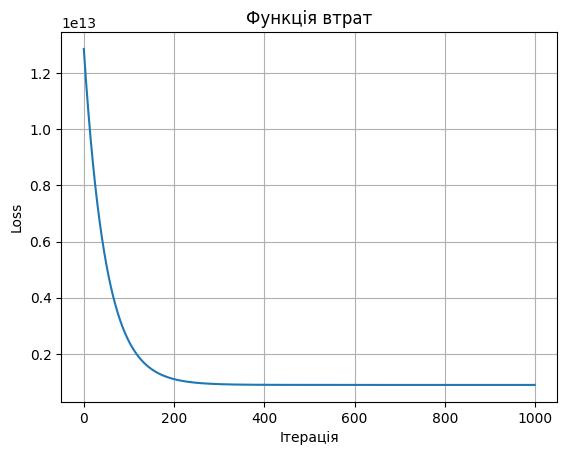

In [85]:
plt.plot(loss_history)
plt.title("Функція втрат")
plt.xlabel("Ітерація")
plt.ylabel("Loss")
plt.grid()
plt.show()

Аналітичне рішення:

In [86]:
w_normal = np.linalg.inv(X.T @ X) @ X.T @ y
print(w_normal)

[4766729.24770642  821214.14349519  695808.52272538  299983.57107963]


In [87]:
X_sklearn = df[["area", "bathrooms", "bedrooms"]]
y_sklearn = df["price"]
Xs_mean = X_sklearn.mean(axis=0)
Xs_std = X_sklearn.std(axis=0)
X_sklearn = (X_sklearn - Xs_mean) / Xs_std
model = LinearRegression()
model.fit(X_sklearn, y_sklearn)
print("Intercept:")
print(model.intercept_)
print()
print("Coefficients:")
print(model.coef_)

Intercept:
4766729.247706422

Coefficients:
[821968.58935343 696447.7589858  300259.16468032]


In [88]:
comparison = pd.DataFrame({

    "Gradient Descent": w,

    "Normal Equation": w_normal

})

comparison

,Gradient Descent,Normal Equation
0,4.766523e+06,4.766729e+06
1,8.211993e+05,8.212141e+05
2,6.955160e+05,6.958085e+05
3,3.002963e+05,2.999836e+05


In [89]:
pred = hypothesis(X, w)
print(pred[:10])

[ 7036428.7494915  10390646.39452105  7591224.59703361  7066729.22087155
  5650961.9640097   8044951.88757889  8861252.36998402 12154616.38770821
  5908515.97074012  5996662.2906585 ]


In [90]:
mse_gradient = mean_squared_error(y, pred)
pred_sklearn = model.predict(X_sklearn)
mse_sklearn = mean_squared_error(y, pred_sklearn)
print("MSE Gradient Descent =", mse_gradient)
print("MSE sklearn =", mse_sklearn)

MSE Gradient Descent = 1791170207770.2297
MSE sklearn = 1791170049977.3193
